In [83]:
import pyreadr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix




# 1. Carga de datos

### carga del dataset

In [2]:
archivo = '../Data/listings.RData'
data_raw = pyreadr.read_r(archivo)


### Vista inicial

In [3]:
data_airbnb = data_raw['listings'].copy()

filas, columnas = data_airbnb.shape

print(data_airbnb.shape)
print(f"{filas:,} filas y {columnas} columnas" )





(171748, 80)
171,748 filas y 80 columnas


In [4]:
print("Dataset vista")
print(list(data_airbnb.columns[:10]))


display(data_airbnb.head(3))

Dataset vista
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id']


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


# 2. Exploración de datos

### Tipos de variables

variables categóricas

In [5]:
data_airbnb['property_type'].value_counts().head()

property_type
Entire rental unit             50810
Entire home                    32898
Entire condo                   23899
Private room in rental unit    15265
Private room in home           13362
Name: count, dtype: int64

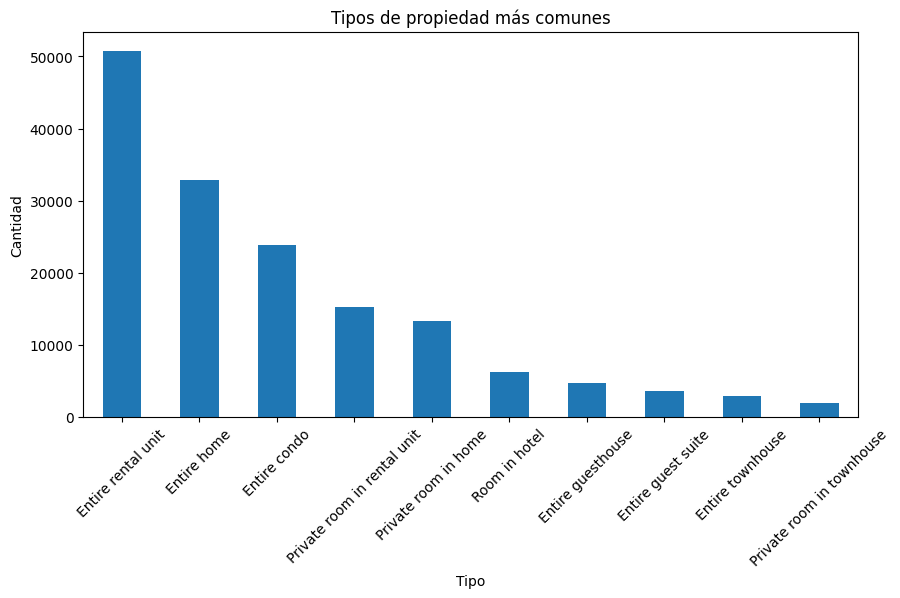

In [6]:
plt.figure(figsize=(10,5))

data_airbnb['property_type'].value_counts().head(10).plot(kind='bar')

plt.title('Tipos de propiedad más comunes')
plt.xlabel('Tipo')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

Variables numéricas

In [7]:
data_airbnb.select_dtypes(include=['number']).columns

Index(['id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'minimum_nights', 'maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month'],
      dtype='str')

### Procesamiento del precio

Vista inicial de precio

In [8]:
print(data_airbnb['price'].head(7).tolist() )

['$97.00', '$160.00', '$38.00', '$145.00', '$58.00', '$49.00', '$300.00']


limpieza de precios sin símbolo

In [9]:
data_airbnb['price_clean'] = (
    data_airbnb['price']
    .str.replace('[$,]', '' , regex=True)
    .str.strip() )


data_airbnb['price_clean'] = pd.to_numeric(data_airbnb['price_clean'], errors='coerce' )

print(data_airbnb['price_clean'].head(8).tolist())

[97.0, 160.0, 38.0, 145.0, 58.0, 49.0, 300.0, 150.0]


##### Valores faltantes

limpieza de valores

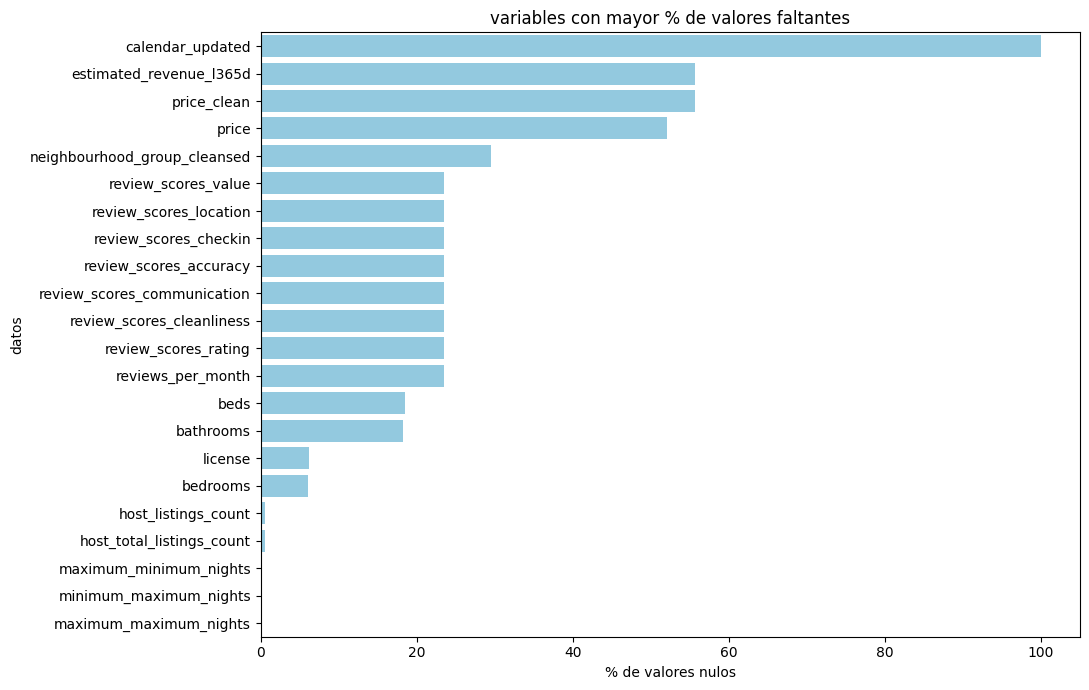

In [10]:
p_nulos = (
    data_airbnb.isnull().sum() / len(data_airbnb) *(100)
).sort_values(ascending=False)

tabla_nulos = p_nulos[p_nulos > 0].reset_index( )
tabla_nulos.columns = ['datos', 'porcentaje_nulo']

plt.figure(figsize=(11, 7))
sns.barplot(
    data=tabla_nulos.head(22), 
    x='porcentaje_nulo', y='datos',
    color='skyblue'
)

plt.title('variables con mayor % de valores faltantes')
plt.xlabel('% de valores nulos')
plt.ylabel('datos')
plt.tight_layout()
plt.show()


In [11]:
vAltos_nulos = (p_nulos > 50).sum()

print(f"Variables con más del 50% de nulos: {vAltos_nulos}")
print()

print("Primeros 10 con más % de nulos")
print(tabla_nulos.head(11))

Variables con más del 50% de nulos: 4

Primeros 10 con más % de nulos
                           datos  porcentaje_nulo
0               calendar_updated       100.000000
1        estimated_revenue_l365d        55.605888
2                    price_clean        55.605888
3                          price        52.041945
4   neighbourhood_group_cleansed        29.510096
5            review_scores_value        23.480914
6         review_scores_location        23.480914
7          review_scores_checkin        23.478585
8         review_scores_accuracy        23.471598
9    review_scores_communication        23.469269
10     review_scores_cleanliness        23.465775


#### Variable respuesta Price

distribución del precio

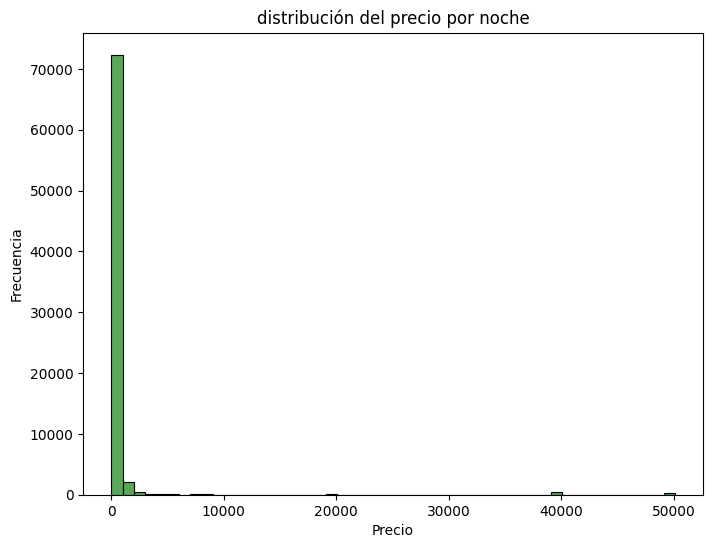

In [12]:
plt.figure(figsize=(8,6))

sns.histplot(data_airbnb['price_clean'], bins=50, color='forestgreen'  )

plt.title('distribución del precio por noche')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')


plt.show()

#### valores atípicos (outliers)

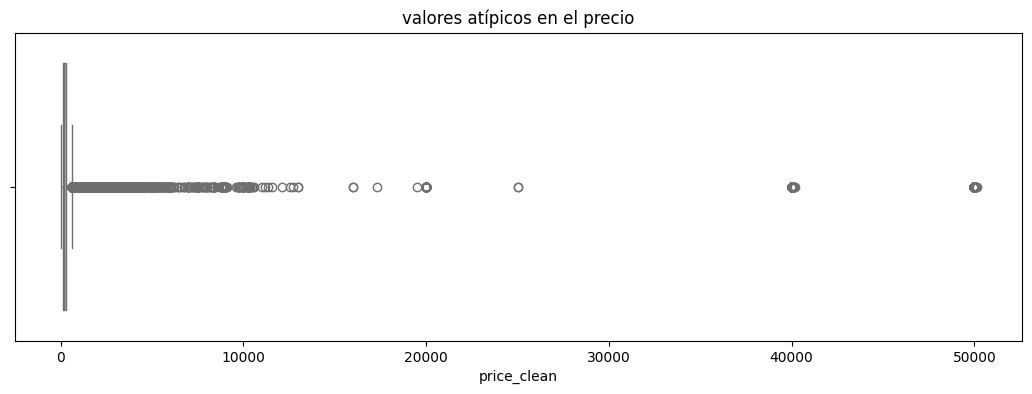

In [13]:
plt.figure(figsize=(13,4))

sns.boxplot(x=data_airbnb['price_clean'], color='skyblue' )

plt.title('valores atípicos en el precio')
plt.show()

#### cuartiles y límite superior

In [14]:
cuartil1 = data_airbnb['price_clean'].quantile(0.25)
cuartil3 = data_airbnb['price_clean'].quantile(0.75)
IQR = cuartil3 - cuartil1

limite_superior = cuartil3+ 1.5 * IQR


print(cuartil1)
print(cuartil3)
print(IQR)
print(limite_superior)

data_sin_outliers = data_airbnb[
    data_airbnb['price_clean'] <= limite_superior
]


120.0
326.0
206.0
635.0


Data sin outliers

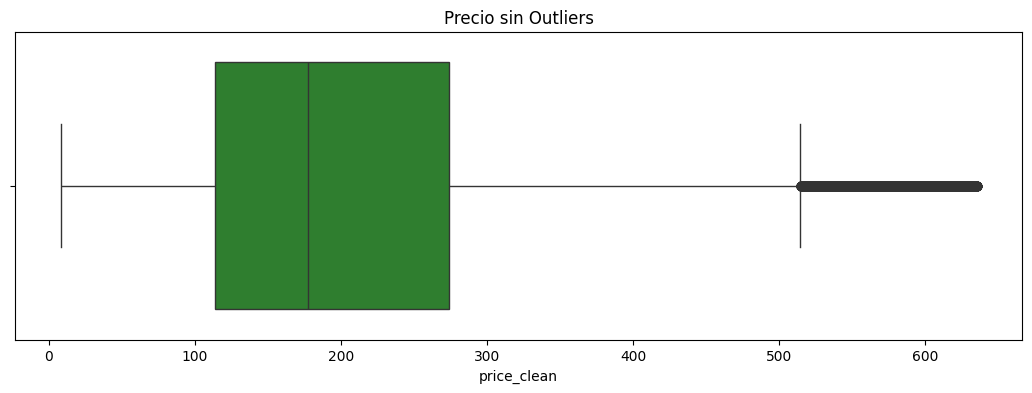

In [15]:
plt.figure(figsize=(13,4))

sns.boxplot(x=data_sin_outliers['price_clean'], color='forestgreen')

plt.title('Precio sin Outliers')
plt.show()

comparación

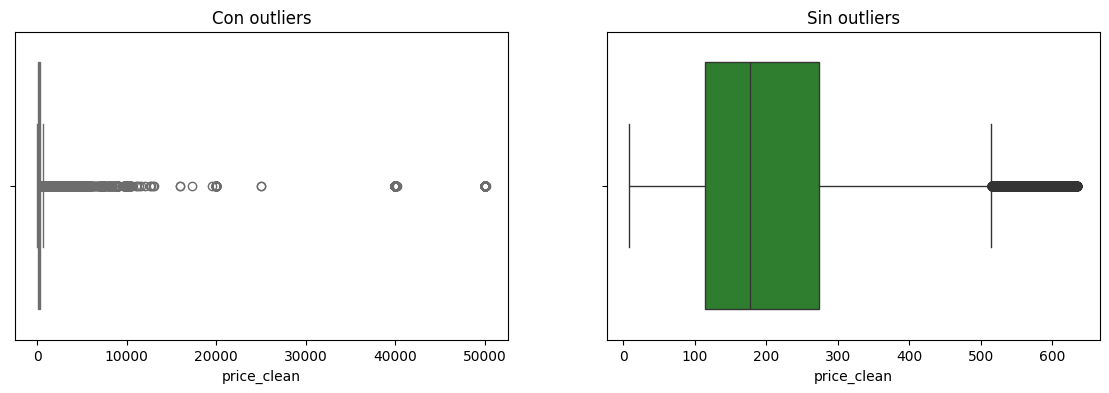

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))


sns.boxplot(x=data_airbnb['price_clean'], ax=axes[0], color='salmon')
axes[0].set_title('Con outliers')

sns.boxplot(x=data_sin_outliers['price_clean'], ax=axes[1], color='forestgreen')
axes[1].set_title('Sin outliers')

plt.show()

#### transformación logarítmica

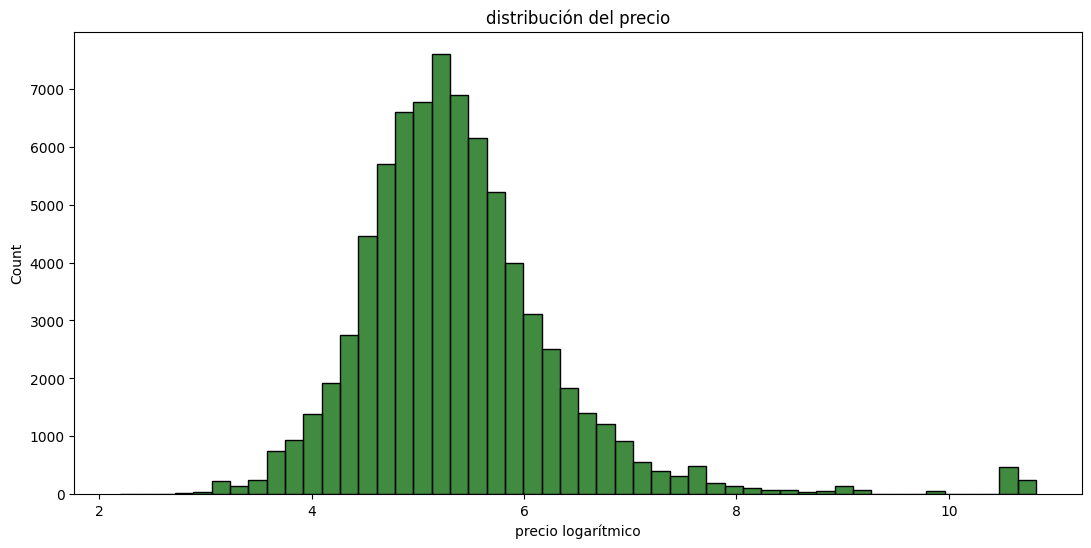

In [17]:
data_airbnb['price_log'] = np.log1p(data_airbnb['price_clean'])

plt.figure(figsize=(13,6))

sns.histplot(data_airbnb['price_log'], bins=50, color='darkgreen')

plt.title('distribución del precio')
plt.xlabel('precio logarítmico' )
plt.show()

#### precio vs variables relevantes

según tipo de habitación

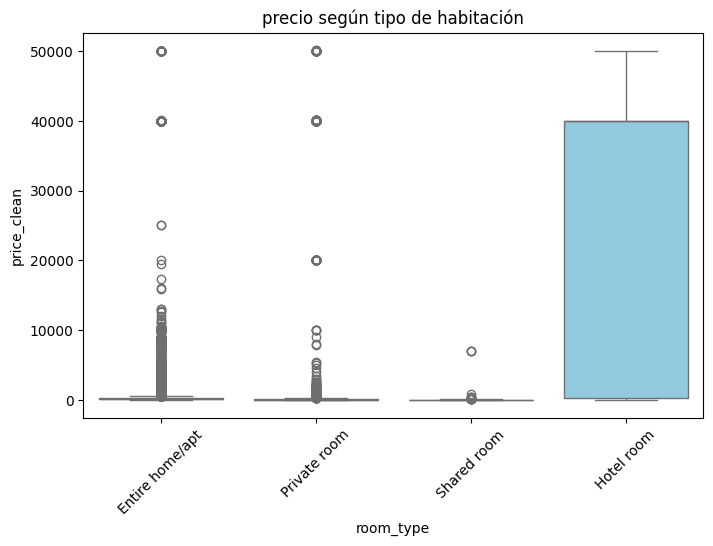

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x='room_type', y='price_clean', data=data_airbnb, color='skyblue'  )

plt.title('precio según tipo de habitación')
plt.xticks(rotation=45)
plt.show()

precio por zona

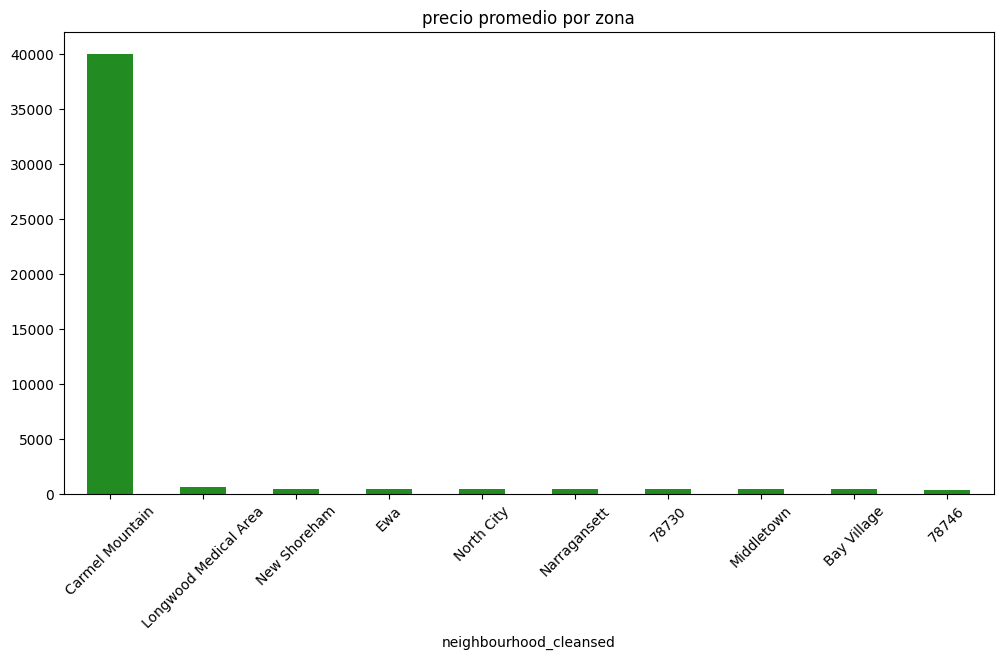

In [19]:


tp_zonas = data_airbnb.groupby('neighbourhood_cleansed')['price_clean'].median().sort_values(ascending=False).head(10)


plt.figure(figsize=(12,6))
tp_zonas.plot(kind='bar', color='forestgreen')
plt.title('precio promedio por zona')

plt.xticks(rotation=45)
plt.show()

frecuencia de zonas

In [20]:
data_airbnb['neighbourhood_cleansed'].value_counts().head(12)


neighbourhood_cleansed
Primary Urban Center    6711
Lahaina                 5254
Kihei-Makena            4459
North Kona              3721
Bedford-Stuyvesant      2613
Midtown                 2587
North Shore Kauai       2329
Williamsburg            2056
South Kohala            1942
Long Beach              1906
Mission Bay             1886
Hollywood               1758
Name: count, dtype: int64

#### matriz de correlación

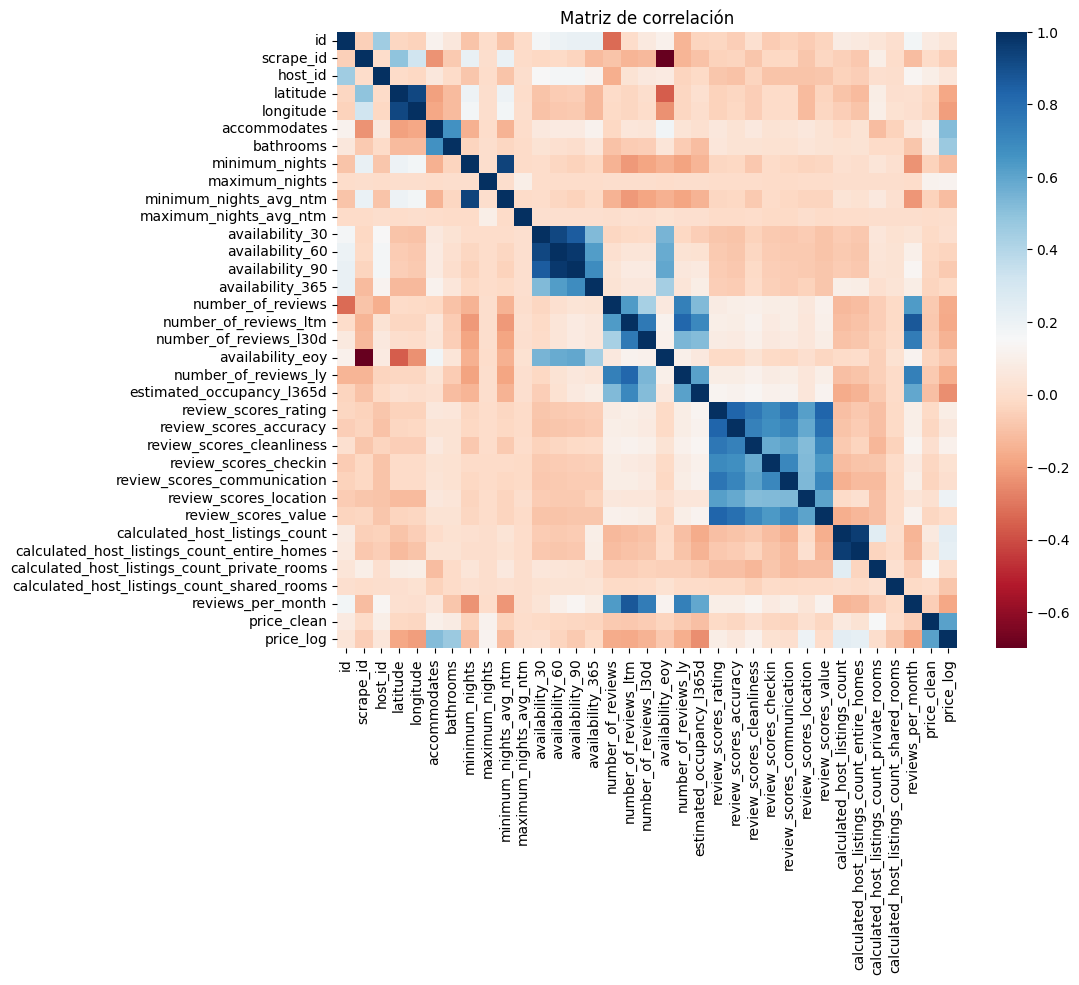

In [21]:
corr = data_airbnb.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='RdBu')
plt.title('Matriz de correlación')
plt.show()

#### selección de variables

In [22]:
features = [
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'number_of_reviews',
    'availability_365'
]

target = 'price_clean'

# 3. Análisis de grupos

In [23]:
data_airbnb.groupby('room_type')['price_clean'].mean()

room_type
Entire home/apt      505.122921
Hotel room         24477.200308
Private room         838.869637
Shared room          149.372093
Name: price_clean, dtype: float64

In [24]:
data_airbnb.groupby('property_type')['price_clean'].median().sort_values(ascending=False).head()

property_type
Hotel room         40000.0
Room in resort      2929.0
Entire home/apt     2174.0
Entire villa         625.0
Lighthouse           552.0
Name: price_clean, dtype: float64

In [25]:
data_airbnb.groupby('neighbourhood_cleansed')['price_clean'].median().sort_values(ascending=False).head()

neighbourhood_cleansed
Carmel Mountain          40000.0
Longwood Medical Area      611.0
New Shoreham               469.0
Ewa                        461.0
North City                 454.0
Name: price_clean, dtype: float64

### Clustering

In [26]:
vars_cluster = [
    'price_clean', 'accommodates',
    'bedrooms',  'beds', 'bathrooms',
    'minimum_nights', 'availability_365',
    'number_of_reviews', 'review_scores_rating'
]

vars_cluster = [col for col in vars_cluster if col in data_airbnb.columns]

data_cluster = data_airbnb[vars_cluster].copy( )

for col in data_cluster.columns:
    data_cluster[col] = pd.to_numeric(data_cluster[col], errors='coerce' )

data_cluster = data_cluster.dropna()

print(f"Datos para K: {data_cluster.shape[0]:,} filas  y {data_cluster.shape[1]} variables" )

Datos para K: 62,722 filas  y 9 variables


In [27]:
escalador = StandardScaler()
datos_escalados = escalador.fit_transform(data_cluster)

#### método del codo

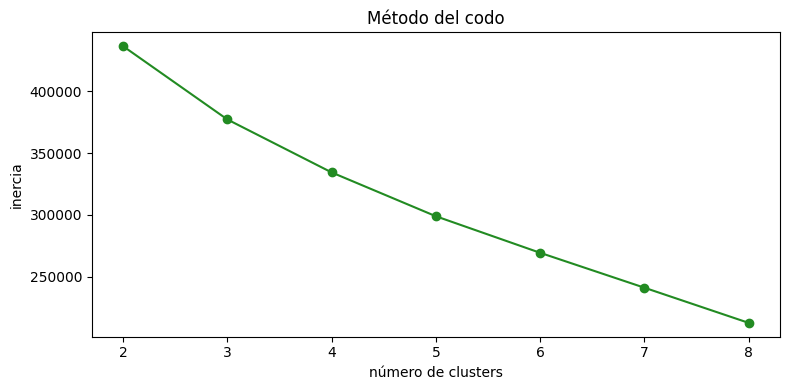

K=2: i=436517
K=3: i=377185
K=4: i=334310
K=5: i=298815
K=6: i=269211
K=7: i=240952
K=8: i=212481


In [28]:
inercias = []
valores_k = range(2, 9)

for k in valores_k:
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_kmeans.fit(datos_escalados)
    inercias.append(modelo_kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(valores_k), inercias, marker='o', color='forestgreen')
plt.title('Método del codo')
plt.xlabel('número de clusters')
plt.ylabel('inercia')
plt.xticks(list(valores_k))
plt.tight_layout()
plt.show()

for k, valor in zip(valores_k, inercias):
    print(f"K={k}: i={valor:.0f}")

In [29]:
k_final = 3

modelo_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
data_cluster['cluster'] = modelo_final.fit_predict(datos_escalados)

#### clusters finales

In [30]:
print("Promedio por cluster:")
print(data_cluster.groupby('cluster' )[vars_cluster].mean().round(2) )

print("\nResumen de precio por cluster:" )
print(data_cluster.groupby('cluster')['price_clean'] .agg(['median', 'mean', 'count']) .round(2) )

Promedio por cluster:
         price_clean  accommodates  bedrooms  beds  bathrooms  minimum_nights  \
cluster                                                                         
0             203.29          3.56      1.24  1.87       1.24            8.12   
1             552.98          8.64      3.46  5.06       2.66            5.40   
2           47681.39          5.83      1.74  1.05       1.64            1.01   

         availability_365  number_of_reviews  review_scores_rating  
cluster                                                             
0                  227.29              72.78                  4.79  
1                  235.75              46.82                  4.85  
2                  208.34               5.55                  4.63  

Resumen de precio por cluster:
          median      mean  count
cluster                          
0          153.0    203.29  46910
1          359.0    552.98  15644
2        50000.0  47681.39    168


#### PCA

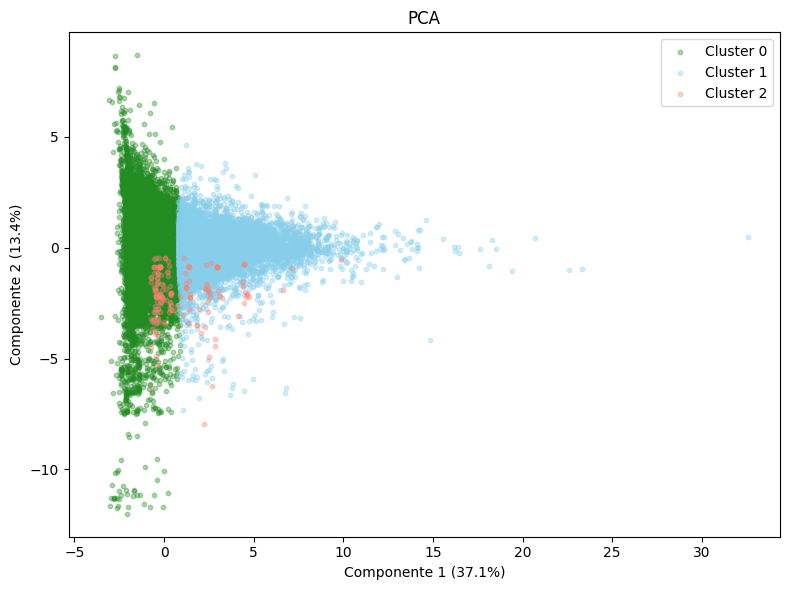

Varianza: 50.4%


In [31]:
modelo_pca = PCA(n_components=2, random_state=42)
coords_pca = modelo_pca.fit_transform(datos_escalados)

plt.figure(figsize=(8, 6) )

colores = ['forestgreen', 'skyblue', 'salmon' ]

for i in range(k_final):
    mascara = data_cluster['cluster'] == i
    plt.scatter( coords_pca[mascara, 0], coords_pca[mascara, 1],  alpha=0.35,  s=10,  color=colores[i], label=f'Cluster {i}' )

plt.title('PCA')

plt.xlabel(f'Componente 1 ({modelo_pca.explained_variance_ratio_[0]:.1%})' )
plt.ylabel(f'Componente 2 ({modelo_pca.explained_variance_ratio_[1]:.1%})')

plt.legend()
plt.tight_layout()
plt.show()

print(f"Varianza: {sum(modelo_pca.explained_variance_ratio_[:2]):.1%}" )

#### precio por cluster

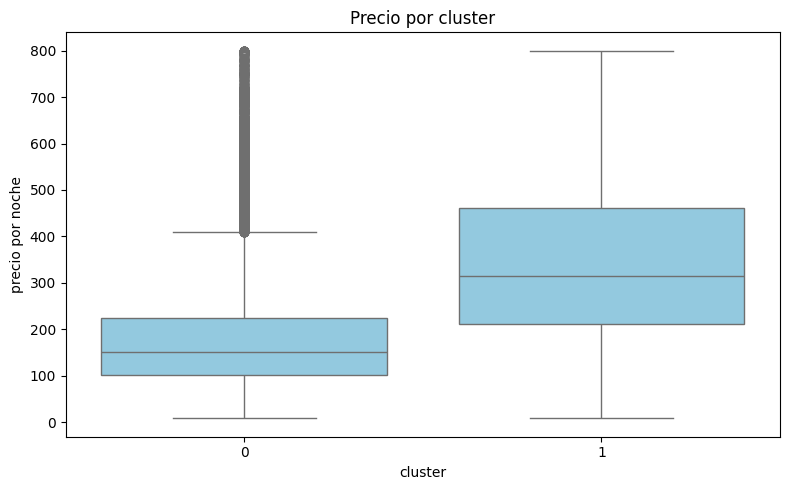

In [32]:
precio_p95 = data_cluster['price_clean'].quantile(0.95)
data_cluster_viz = data_cluster[data_cluster['price_clean'] <= precio_p95 ]

plt.figure(figsize=(8 , 5) )

sns.boxplot(x='cluster', y='price_clean', data=data_cluster_viz, color='skyblue' )

plt.title('Precio por cluster' )
plt.xlabel('cluster')
plt.ylabel('precio por noche') 
plt.tight_layout()
plt.show()

#### Normalización de los clusters

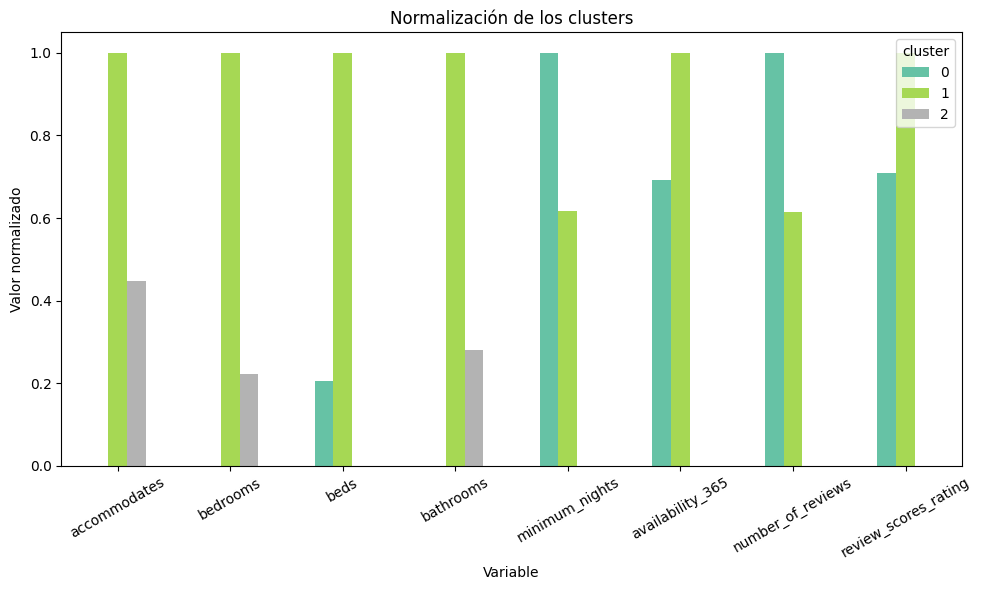

In [33]:
vars_perfil = [col for col in vars_cluster if col != 'price_clean' ]

perfil_cluster = data_cluster.groupby('cluster')[vars_perfil].mean()

perfil_normalizado = (perfil_cluster - perfil_cluster.min()) / (perfil_cluster.max() - perfil_cluster.min() )

perfil_normalizado.T.plot(kind='bar', figsize=(10, 6), colormap='Set2')

plt.title('Normalización de los clusters' )
plt.xlabel('Variable')
plt.ylabel('Valor normalizado' )
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 4. División

In [34]:
from sklearn.model_selection import train_test_split

X = data_sin_outliers[features]
y = data_sin_outliers[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

total = len(X_train) + len(X_test)

print(f"Tamaño Train: shape {X_train.shape}, ({len(X_train)/total*100:.1f}%)")
print(f"Tamaño Test: shape {X_test.shape}, ({len(X_test)/total*100:.1f}%)")

Tamaño Train: shape (48115, 6), (70.0%)
Tamaño Test: shape (20622, 6), (30.0%)


In [35]:
print(f"Total datos: {len(X)}")

Total datos: 68737


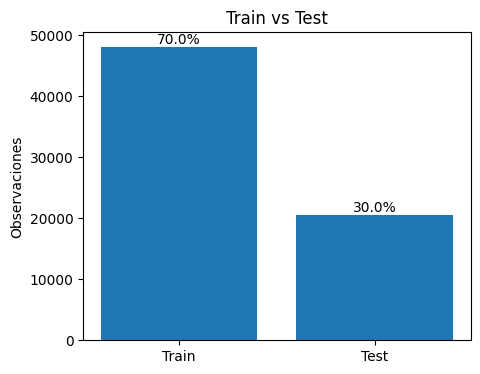

In [36]:
sizes = [len(X_train), len(X_test)]
labels = ['Train', 'Test']
porcentajes = [s / sum(sizes) * 100 for s in sizes ]

plt.figure(figsize=(5, 4))
bars = plt.bar(labels, sizes)

for i, bar in enumerate(bars): plt.text(bar.get_x() +  bar.get_width()/2, bar.get_height(), f"{porcentajes[i]:.1f}%", ha='center', va='bottom')

plt.title('Train vs Test')
plt.ylabel('Observaciones')
plt.show()

# 5. árbol de regresión

#### ejes

In [37]:
X = data_sin_outliers.drop(columns=['price', 'price_clean', 'price_log'], errors='ignore')
y = data_sin_outliers['price_clean']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [38]:
columnas_numericas = X_train.select_dtypes(include=['number']).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Columnas numéricas:", len(columnas_numericas))
print("Columnas categóricas:", len(columnas_categoricas))

Columnas numéricas: 33
Columnas categóricas: 46


C:\Users\agabr\AppData\Local\Temp\ipykernel_31524\3891230269.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


#### pipelines con OneHotEncoder

In [39]:
preprocesador = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            
            columnas_numericas
        ),
        (
            'cat',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            
            columnas_categoricas
        )
    ]
)


#### modelo

In [40]:
modelo_arbol = Pipeline(steps=[
    ('prep', preprocesador),
    ('tree', DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ))
])

modelo_arbol.fit(X_train, y_train)

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['calendar_updated']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [41]:
y_pred_train = modelo_arbol.predict(X_train)
y_pred_test = modelo_arbol.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)

mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print(f"MAE Train: {mae_train}")
print(f"MAE Test: {mae_test}")
print()
print(f"MSE Train: {mse_train}")
print(f"MSE Test: {mse_test}")
print()
print(f"RMSE Train: {rmse_train:}")
print(f"RMSE Test: {rmse_test:}")

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['calendar_updated']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['calendar_updated']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.

MAE Train: 57.029403882827076
MAE Test: 61.513085792011644

MSE Train: 6417.5669735014635
MSE Test: 7612.641456713679

RMSE Train: 80.10971834616237
RMSE Test: 87.25045247283064


In [42]:
tabla_metricas = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE'],
    'Train': [mae_train, mse_train, rmse_train],
    'Test': [mae_test, mse_test, rmse_test]
})

tabla_metricas

,Métrica,Train,Test
0,MAE,57.029404,61.513086
1,MSE,6417.566974,7612.641457
2,RMSE,80.109718,87.250452


#### comparación de errores

In [43]:
y_pred = modelo_arbol.predict(X_test)

comparacion = pd.DataFrame({
    'real': y_test.values,
    'predicho': y_pred
})

display(comparacion.head(8))

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['calendar_updated']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


,real,predicho
0,233.0,278.640000
1,89.0,135.029757
2,225.0,228.415743
3,249.0,196.223214
4,289.0,446.667774
5,140.0,151.947090
6,303.0,296.237374
7,129.0,168.486911


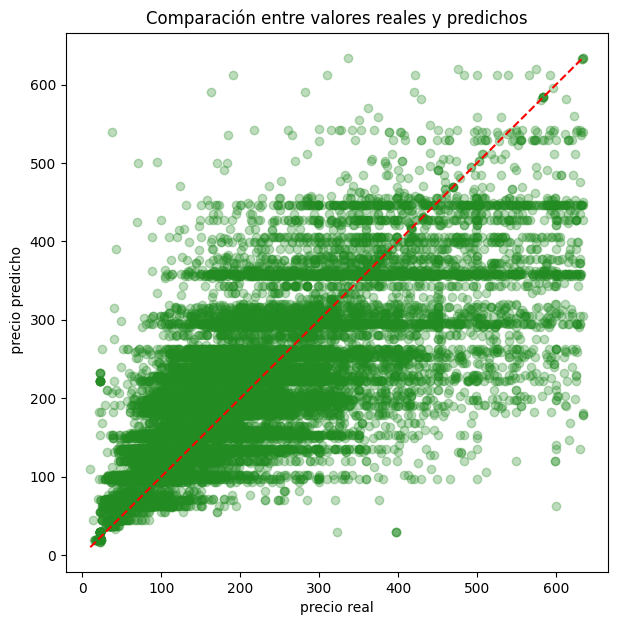

In [44]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.3, color='forestgreen')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)
plt.xlabel('precio real')
plt.ylabel(' precio predicho')
plt.title('Comparación entre valores reales y predichos')
plt.show()

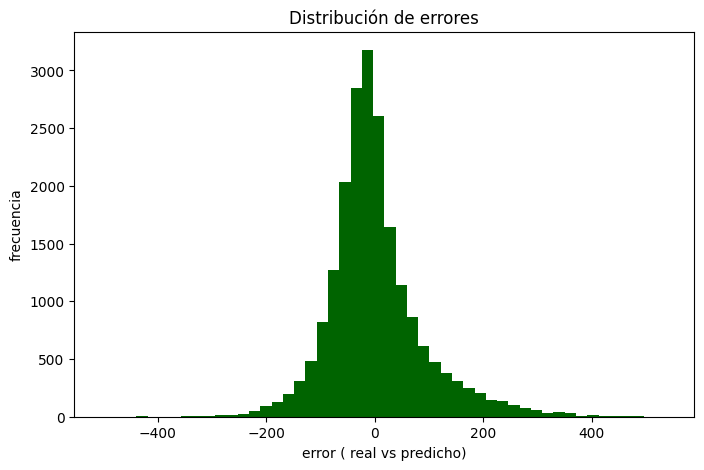

In [45]:
errores = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(errores, bins=50, color='darkgreen')
plt.title('Distribución de errores')
plt.xlabel('error ( real vs predicho)')
plt.ylabel('frecuencia')
plt.show()

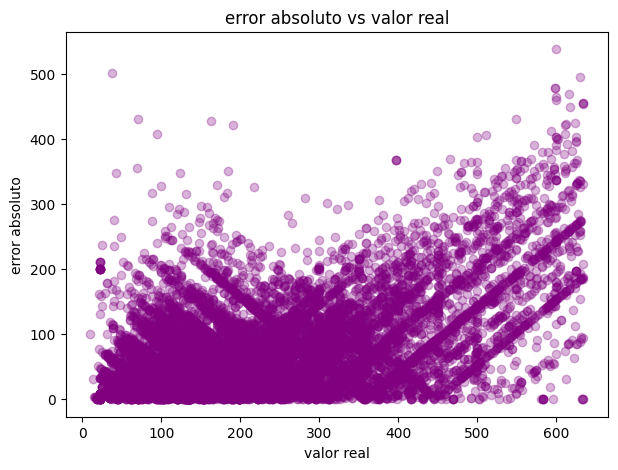

In [46]:
error_abs = abs(y_test - y_pred)

plt.figure(figsize=(7,5))
plt.scatter(y_test, error_abs, alpha=0.3, color='purple')

plt.xlabel('valor real')
plt.ylabel('error absoluto')
plt.title('error absoluto vs valor real')

plt.show()

#### R²

In [47]:
r2 = r2_score(y_test, y_pred)
print(f" El R²: {r2:.4f}" )

 El R²: 0.5446


#### importancia

In [48]:
tree = modelo_arbol.named_steps['tree' ]


preprocessor = modelo_arbol.named_steps['prep' ]


nombres = preprocessor.get_feature_names_out()

In [49]:
importancias = pd.Series(
    tree.feature_importances_,  index=nombres
).sort_values(ascending=False)

print(importancias.head(12))

num__bathrooms                                               0.375424
num__accommodates                                            0.158557
num__longitude                                               0.072789
num__latitude                                                0.059478
cat__license_                                                0.036809
cat__neighbourhood_group_cleansed_Honolulu                   0.034421
num__review_scores_location                                  0.027411
num__calculated_host_listings_count_entire_homes             0.024212
cat__host_name_Eich                                          0.018846
num__estimated_occupancy_l365d                               0.011941
cat__host_url_https://www.airbnb.com/users/show/446820235    0.008069
cat__license_Exempt                                          0.007914
dtype: float64


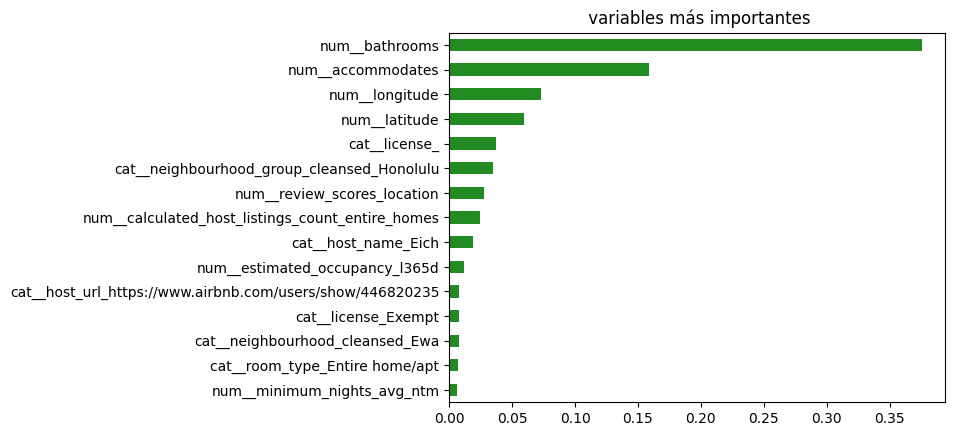

In [50]:
importancias.head(15).plot(kind='barh', color='forestgreen')
plt.title(' variables más importantes')
plt.gca().invert_yaxis()
plt.show()

## 6. Evaluación del árbol de regresión

In [51]:
y_pred_train = modelo_arbol.predict(X_train)
y_pred_test  = modelo_arbol.predict(X_test)

mse = mean_squared_error(y_test, y_pred_test) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("Evaluación del árbol de regresión:")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['calendar_updated']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['calendar_updated']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.

Evaluación del árbol de regresión:
RMSE: 87.25
R²: 0.5446


In [52]:
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)


mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

tabla_metricas = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Train': [mae_train, mse_train, rmse_train, r2_train],
    'Test':  [mae_test, mse_test, rmse_test, r2_test]
})

tabla_metricas

,Métrica,Train,Test
0,MAE,57.029404,61.513086
1,MSE,6417.566974,7612.641457
2,RMSE,80.109718,87.250452
3,R²,0.610704,0.544585


In [53]:
tabla_resumen = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Train': [mae_train, mse_train, rmse_train, r2_train],
    'Test': [mae_test, mse_test, rmse_test, r2_test]
})

tabla_resumen['Diferencia'] = tabla_resumen['Test'] - tabla_resumen['Train']
tabla_resumen['Ratio Test/Train'] = tabla_resumen['Test'] / tabla_resumen['Train']

tabla_resumen.round(4)



,Métrica,Train,Test,Diferencia,Ratio Test/Train
0,MAE,57.0294,61.5131,4.4837,1.0786
1,MSE,6417.5670,7612.6415,1195.0745,1.1862
2,RMSE,80.1097,87.2505,7.1407,1.0891
3,R²,0.6107,0.5446,-0.0661,0.8917


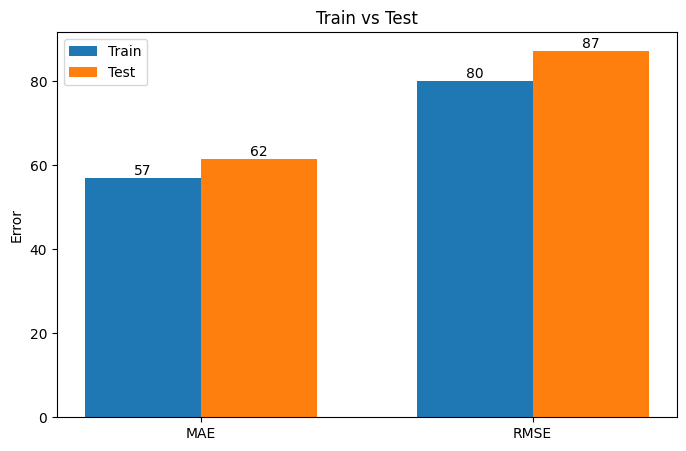

In [54]:
metricas = ['MAE', 'RMSE']
train_vals = [mae_train, rmse_train]
test_vals  = [mae_test, rmse_test]

x = np.arange(len(metricas))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width/2, train_vals, width, label='Train')
bars2 = plt.bar(x + width/2, test_vals, width, label='Test')

plt.xticks(x, metricas)
plt.ylabel('Error')
plt.title('Train vs Test')

plt.legend()

for bar in bars1:
    plt.text(bar.get_x() +  bar.get_width()/2, bar.get_height(), f'{bar.get_height():.0f}', ha='center', va='bottom')

for bar in bars2:
    plt.text(bar.get_x() +  bar.get_width()/2, bar.get_height(), f'{bar.get_height():.0f}', ha='center', va='bottom')

plt.show()

## 7. Ajuste de parámetros del árbol

In [55]:
profundidades = [3, 5, 10, 12 , 15, 20]

resultados = []

for d in profundidades:
    
    modelo = Pipeline(steps=[
        ('prep', preprocesador),
        ('tree', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    
    modelo.fit(X_train, y_train)
    
    y_pred_train = modelo.predict(X_train)
    y_pred_test  = modelo.predict(X_test)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test, y_pred_test)
    
    resultados.append((d, rmse_train, rmse_test, r2_train, r2_test))

for r in resultados:
    print(f"Profundidad: {r[0]} | RMSE Train: {r[1]:.2f} | RMSE Test: {r[2]:.2f} | R2 Train: {r[3]:.3f} | R2 Test: {r[4]:.3f}")

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['calendar_updated']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-pac

Profundidad: 3 | RMSE Train: 104.73 | RMSE Test: 104.85 | R2 Train: 0.335 | R2 Test: 0.342
Profundidad: 5 | RMSE Train: 97.03 | RMSE Test: 98.26 | R2 Train: 0.429 | R2 Test: 0.422
Profundidad: 10 | RMSE Train: 80.11 | RMSE Test: 87.25 | R2 Train: 0.611 | R2 Test: 0.545
Profundidad: 12 | RMSE Train: 72.65 | RMSE Test: 86.35 | R2 Train: 0.680 | R2 Test: 0.554
Profundidad: 15 | RMSE Train: 60.88 | RMSE Test: 87.98 | R2 Train: 0.775 | R2 Test: 0.537
Profundidad: 20 | RMSE Train: 42.27 | RMSE Test: 91.08 | R2 Train: 0.892 | R2 Test: 0.504


In [56]:
tabla_modelos = pd.DataFrame(resultados, columns=[
    'Profundidad', 'RMSE Train', 'RMSE Test', 'R2 Train', 'R2 Test'
])

tabla_modelos


,Profundidad,RMSE Train,RMSE Test,R2 Train,R2 Test
0,3,104.728271,104.847719,0.334670,0.342357
1,5,97.033121,98.262469,0.428851,0.422373
2,10,80.109718,87.250452,0.610704,0.544585
3,12,72.653741,86.350054,0.679797,0.553936
4,15,60.882105,87.979246,0.775152,0.536945
5,20,42.267660,91.083615,0.891626,0.503690


## 8. Comparación con regresión lineal

In [57]:
from sklearn.linear_model import LinearRegression


modelo_lr = Pipeline(steps=[ ('prep', preprocesador), ('lr', LinearRegression()) ])

modelo_lr.fit(X_train, y_train)


y_pred_lr = modelo_lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
mse= mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Regresión lineal inicial:")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['calendar_updated']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-pac

Regresión lineal inicial:
RMSE: 129.27
R2: 0.0003


#### regresión lineal con log

In [58]:
data_sin_outliers['price_log'] = np.log1p(data_sin_outliers['price_clean'])


numeric_features = [  'accommodates' , 'bedrooms', 'beds', 'bathrooms', 'number_of_reviews', 'availability_365' ]

categorical_features = [  'room_type' , 'neighbourhood_cleansed' ]

X = data_sin_outliers[numeric_features + categorical_features]
y = data_sin_outliers['price_log']




X_train, X_test, y_train, y_test = train_test_split( X, y,  test_size=0.3,    random_state=42 )


numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocesador = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])


modelo

In [59]:
modelo_lr = Pipeline([ ('prep', preprocesador),  ('lr', LinearRegression()) ])


modelo_lr.fit(X_train, y_train)


y_pred_log = modelo_lr.predict(X_test)


y_pred = np.expm1(y_pred_log)
y_real = np.expm1(y_test)

y_pred_lr_log_real = np.expm1(y_pred_log)
y_real_log = np.expm1(y_test)



mae_log = mean_absolute_error(y_real, y_pred)
rmse_log = np.sqrt(mean_squared_error(y_real, y_pred))
r2_log = r2_score(y_real, y_pred)

print("Regresión lineal con transformación logarítmica:")
print(f"MAE:  {mae_log}")
print(f"RMSE: {rmse_log}")
print(f"R2:   {r2_log}")

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Regresión lineal con transformación logarítmica:
MAE:  65.42049930852272
RMSE: 97.39907662159176
R2:   0.43247895151906823


c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


#### comparación

In [60]:
tabla_lr = pd.DataFrame({
    'Modelo': ['Lineal inicial', 'Lineal con log'],
    'MAE': [mae, mae_log],
    'RMSE': [rmse, rmse_log],
    'R2': [r2, r2_log]
})

display(tabla_lr.round(4))

,Modelo,MAE,RMSE,R2
0,Lineal inicial,101.3965,129.2704,0.0003
1,Lineal con log,65.4205,97.3991,0.4325


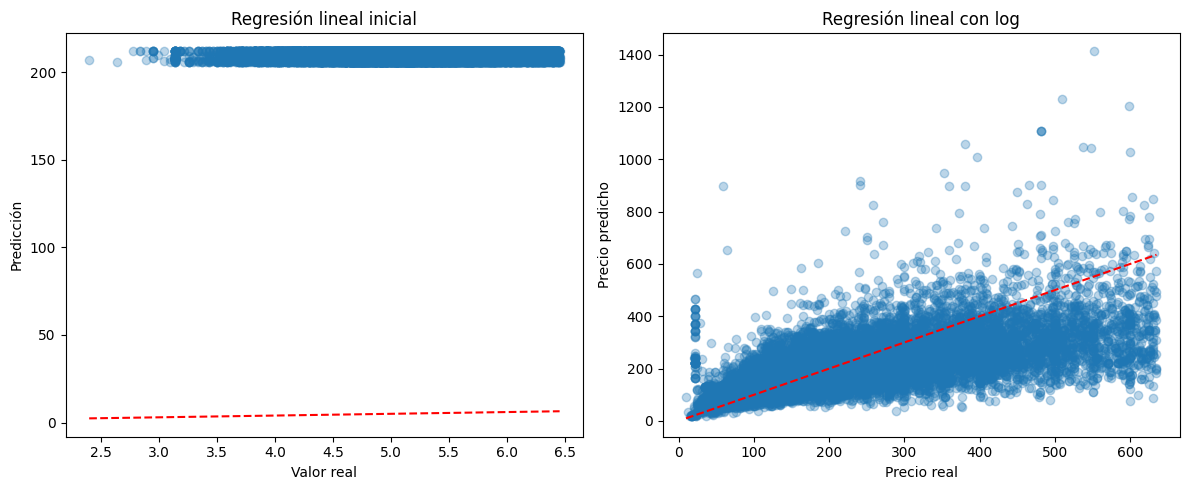

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].scatter(y_test, y_pred_lr, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')
axes[0].set_title('Regresión lineal inicial')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Predicción')

axes[1].scatter(y_real_log, y_pred_lr_log_real, alpha=0.3)
axes[1].plot([y_real_log.min(), y_real_log.max()],
             [y_real_log.min(), y_real_log.max()],
             'r--')
axes[1].set_title('Regresión lineal con log')
axes[1].set_xlabel('Precio real')
axes[1].set_ylabel('Precio predicho')

plt.tight_layout()
plt.show()

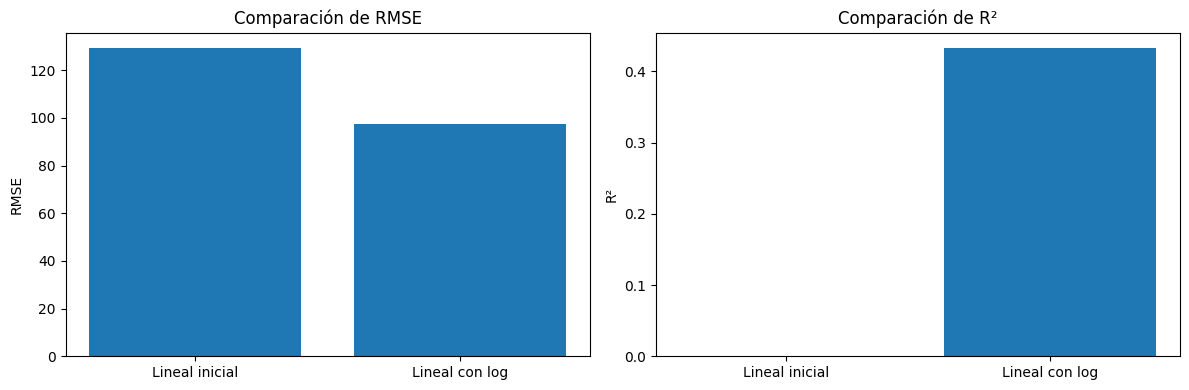

In [62]:
modelos = ['Lineal inicial', 'Lineal con log']
rmse_vals = [rmse, rmse_log]
r2_vals = [r2, r2_log]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(modelos, rmse_vals)
axes[0].set_title('Comparación de RMSE')
axes[0].set_ylabel('RMSE')

axes[1].bar(modelos, r2_vals)
axes[1].set_title('Comparación de R²')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

In [63]:
resultados_finales = pd.DataFrame({
    'Modelo': ['Árbol de regresión (depth=12)', 'Regresión lineal inicial'],
    'RMSE': [0.450135, rmse],
    'R2': [0.495718, r2]
})

display(resultados_finales.round(4))

,Modelo,RMSE,R2
0,Árbol de regresión (depth=12),0.4501,0.4957
1,Regresión lineal inicial,129.2704,0.0003


## 9. Creación de variable categórica

In [64]:
data_airbnb['price_clean'].describe()

count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price_clean, dtype: float64

In [65]:
q1 = data_sin_outliers['price_clean'].quantile(0.33)
q2 = data_sin_outliers['price_clean'].quantile(0.66)

def clasificar_precio(p):
    if p <= q1:
        return 'Económica'
    elif p <= q2:
        return 'Intermedia'
    else:
        return 'Cara'

data_sin_outliers['price_category'] = data_sin_outliers['price_clean'].apply(clasificar_precio)

print(data_sin_outliers['price_category'].value_counts())

price_category
Cara          23335
Económica     22870
Intermedia    22532
Name: count, dtype: int64


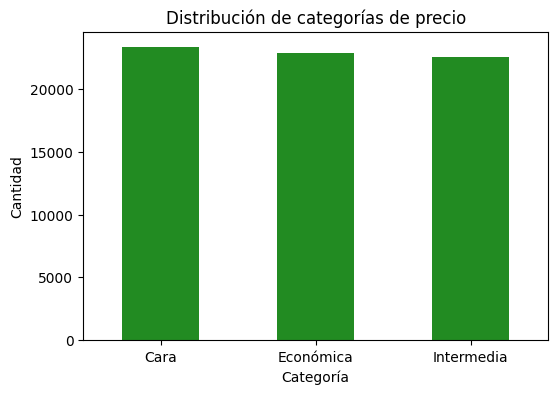

In [66]:
plt.figure(figsize=(6,4))
data_sin_outliers['price_category'].value_counts().plot(kind='bar', color='forestgreen')

plt.title('Distribución de categorías de precio')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')

plt.xticks(rotation=0)
plt.show()

In [67]:
X = data_sin_outliers.drop(columns=['price_category', 'price_clean'])
y = data_sin_outliers['price_category']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [70]:
numeric_features = features

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocesador_clf = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features)
])

## 10. Árbol de clasificación

#### Definición de variables y clasificación 

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


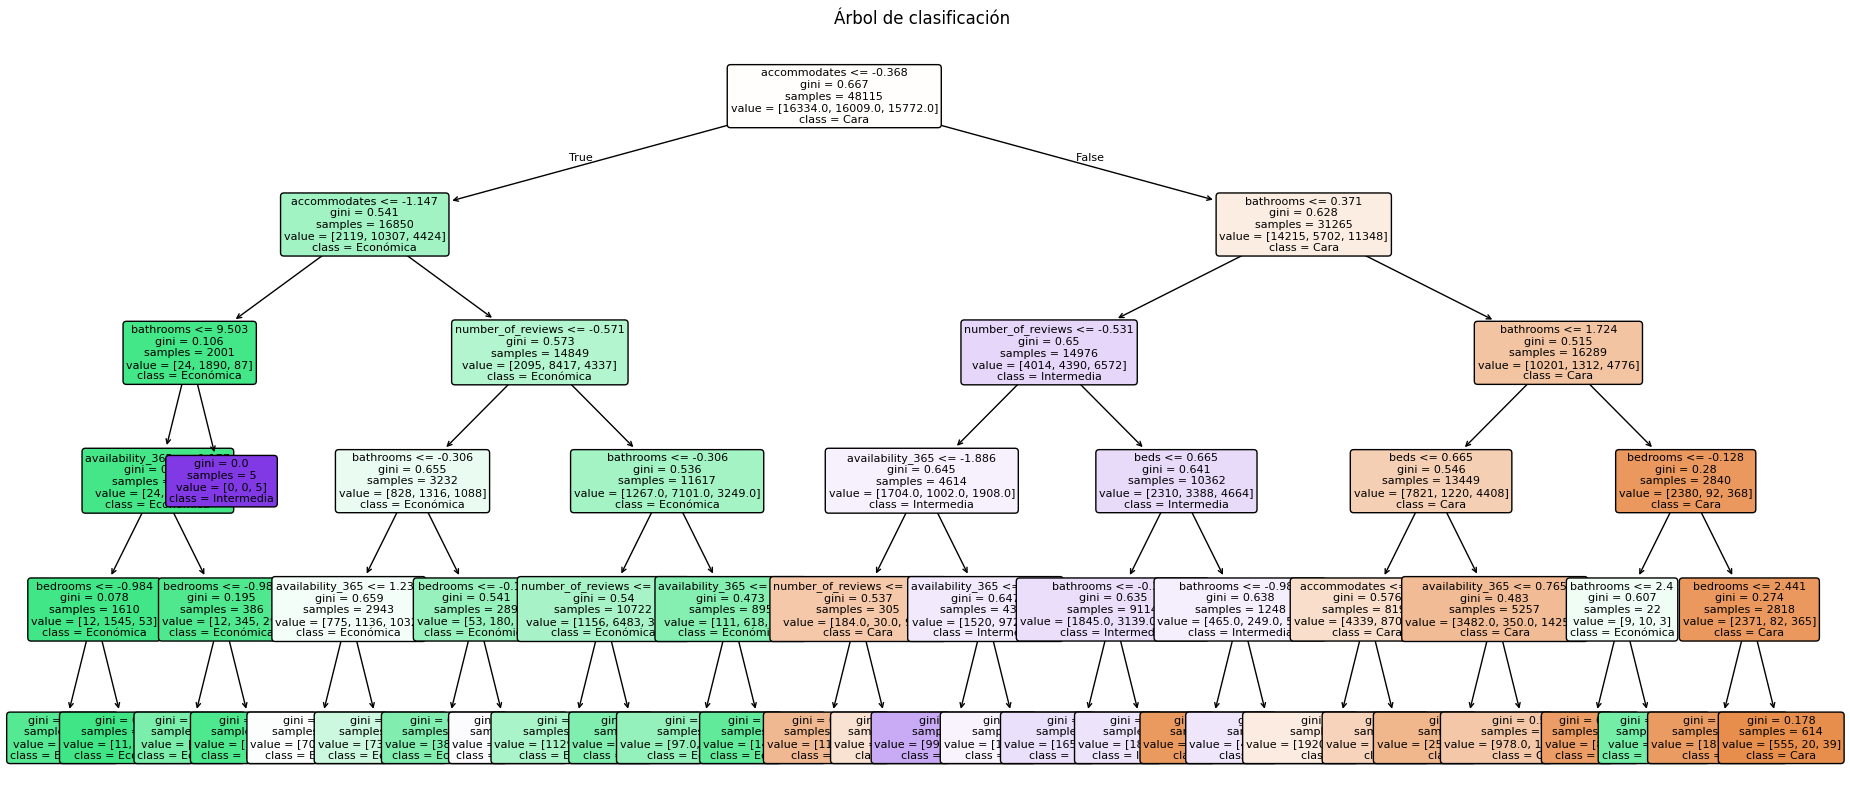

In [71]:
features= [ 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'number_of_reviews', 'availability_365' ]

target= 'price_category'

X = data_sin_outliers[features]
y = data_sin_outliers[target]


X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(   X, y,  test_size=0.3,  random_state=42 ,  stratify=y )


modelo_clf = Pipeline(steps=[
    ('prep', preprocesador_clf),
    ('tree', DecisionTreeClassifier(
        criterion='gini',
        max_depth=5,
        random_state=42
    ))
])

modelo_clf.fit(X_train_clf, y_train_clf)

plt.figure(figsize=(23, 10 ))

plot_tree(
    modelo_clf.named_steps['tree'],
    feature_names=features,
    class_names=modelo_clf.named_steps['tree'].classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Árbol de clasificación')
plt.show()

# 11. Eficiencia

In [72]:
y_pred_clf = modelo_clf.predict(X_test_clf)


accuracy = accuracy_score(y_test_clf, y_pred_clf)

precision = precision_score(y_test_clf , y_pred_clf, average='weighted')

recall = recall_score(y_test_clf, y_pred_clf , average='weighted' )
f1 = f1_score(y_test_clf, y_pred_clf , average='weighted' )

print("Evaluación del modelo de clasificación:\n")
print(f"Accuracy: {accuracy:.4f}" )

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nReporte de clasificación:\n")
print(classification_report(y_test_clf, y_pred_clf ) )

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Evaluación del modelo de clasificación:

Accuracy: 0.5672
Precision: 0.5626
Recall: 0.5672
F1-score: 0.5644

Reporte de clasificación:

              precision    recall  f1-score   support

        Cara       0.63      0.64      0.63      7001
   Económica       0.61      0.65      0.63      6861
  Intermedia       0.44      0.41      0.43      6760

    accuracy                           0.57     20622
   macro avg       0.56      0.57      0.56     20622
weighted avg       0.56      0.57      0.56     20622



# 12. matriz de confusión 

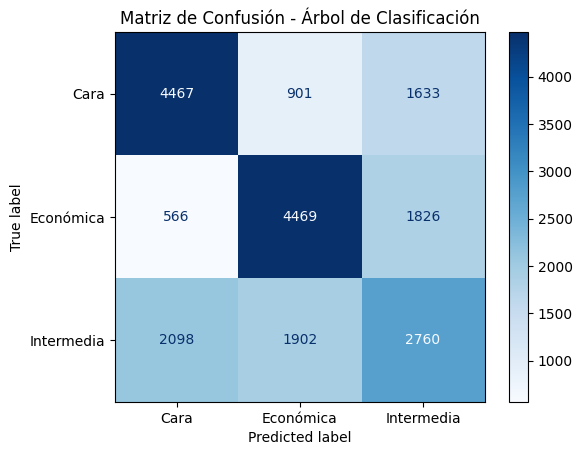

In [73]:
cm = confusion_matrix(y_test_clf, y_pred_clf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_clf.classes_)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Árbol de Clasificación")
plt.show()

# 13. validacion cruzada

In [77]:
scores = cross_val_score(modelo_clf, X_train_clf, y_train_clf, cv=5, scoring='accuracy')

print("Scores por fold:", scores)
print("Accuracy promedio:", scores.mean())

y_pred_cv = cross_val_predict(modelo_clf, X_train_clf, y_train_clf, cv=5)

acc_cv = accuracy_score(y_train_clf, y_pred_cv)

print("\nAccuracy con validación cruzada:", acc_cv)

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encoun

Scores por fold: [0.56946898 0.56188299 0.56271433 0.56375351 0.5595968 ]
Accuracy promedio: 0.563483321209602


c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encoun


Accuracy con validación cruzada: 0.563483321209602


c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


# 14. diferentes profundidades 

In [80]:
resultados = []

for depth in [3, 5, 10, 15, 20]:

    modelo_temp = Pipeline([
        ('prep', preprocesador_clf),
        ('tree', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])

    modelo_temp.fit(X_train_clf, y_train_clf)

    y_pred_temp = modelo_temp.predict(X_test_clf)

    acc = accuracy_score(y_test_clf, y_pred_temp)

    print(f"Profundidad {depth} -> Accuracy: {acc:.4f}")

    resultados.append((depth, acc))

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Profundidad 3 -> Accuracy: 0.5634


c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Profundidad 5 -> Accuracy: 0.5672


c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Profundidad 10 -> Accuracy: 0.5748


c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Profundidad 15 -> Accuracy: 0.5562


c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Profundidad 20 -> Accuracy: 0.5283


c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [87]:
best = max(resultados, key=lambda x: x[1])
print(f"\nMejor profundidad: {best[0]} con accuracy: {best[1]:.4f}")


Mejor profundidad: 10 con accuracy: 0.5748


# 15. random forest 

In [85]:
modelo_rf = Pipeline([
    ('prep', preprocesador_clf),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

modelo_rf.fit(X_train_clf, y_train_clf)

y_pred_rf = modelo_rf.predict(X_test_clf)

acc_rf = accuracy_score(y_test_clf, y_pred_rf)

print("Random Forest - Accuracy:", acc_rf)

print("\nReporte de clasificación:\n")
print(classification_report(y_test_clf, y_pred_rf))

c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\agabr\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Random Forest - Accuracy: 0.5851032877509456

Reporte de clasificación:

              precision    recall  f1-score   support

        Cara       0.63      0.67      0.65      7001
   Económica       0.62      0.68      0.65      6861
  Intermedia       0.47      0.40      0.43      6760

    accuracy                           0.59     20622
   macro avg       0.58      0.58      0.58     20622
weighted avg       0.58      0.59      0.58     20622



### matriz de confusión 

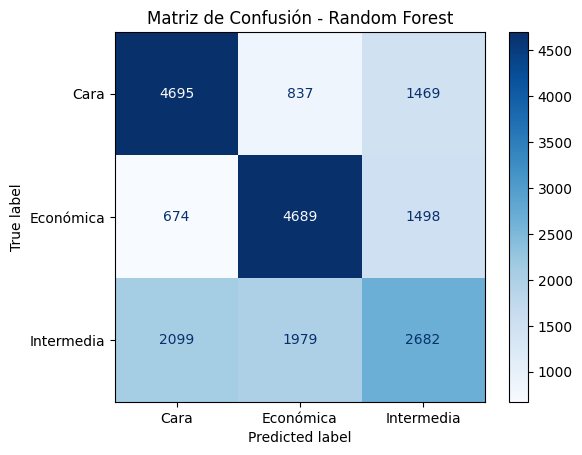

In [86]:
cm_rf = confusion_matrix(y_test_clf, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=modelo_rf.named_steps['rf'].classes_)
disp.plot(cmap='Blues')

plt.title("Matriz de Confusión - Random Forest")
plt.show()